# Task
What are the primary causes of death among migrants, and have these causes shifted over the years?

Here is all the data you need:
"final_df_with_climate_and_policy.csv"

## Data loading

### Subtask:
Load the dataset "final_df_with_climate_and_policy.csv" into a pandas DataFrame.


**Reasoning**:
Load the dataset "final_df_with_climate_and_policy.csv" into a pandas DataFrame and display its first few rows and shape.



In [ ]:
import pandas as pd

try:
    df = pd.read_csv('final_df_with_climate_and_policy.csv')
    display(df.head())
    print(df.shape)
except FileNotFoundError:
    print("Error: 'final_df_with_climate_and_policy.csv' not found.")
    df = None
except pd.errors.ParserError:
    print("Error: Could not parse the CSV file. Check the file format.")
    df = None
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    df = None

,Incident Date,year,month,state,Total Number of Dead and Missing,Cause of Death,average_temp,Migration Route,geometry
0,2014-01-06,2014.0,1,ARIZONA,1,Mixed or unknown,44.0,US-Mexico border crossing,POINT (-110.366453 31.650259)
1,2014-01-12,2014.0,1,ARIZONA,1,Mixed or unknown,44.0,US-Mexico border crossing,POINT (-111.73756 31.59713)
2,2014-01-14,2014.0,1,NaN,1,Mixed or unknown,NaN,US-Mexico border crossing,POINT (-113.01125 31.94026)
3,2014-01-16,2014.0,1,ARIZONA,1,Violence,44.0,US-Mexico border crossing,POINT (-109.315632 31.506777)
4,2014-01-17,2014.0,1,ARIZONA,1,Mixed or unknown,44.0,US-Mexico border crossing,POINT (-113.18402 32.45435)


(4308, 9)


## Data exploration

### Subtask:
Explore the dataset to understand its structure, identify relevant columns, and check for missing values.


**Reasoning**:
I need to examine the data types and descriptive statistics, identify relevant columns, check for missing values, explore unique values in key columns, and print the data shape. All of these can be done in one code block.



In [ ]:
# Examine data types and descriptive statistics
print(df.info())
print(df.describe())

# Identify relevant columns
relevant_columns = ['year', 'Cause of Death', 'Total Number of Dead and Missing', 'Migration Route']
print(f"\nRelevant Columns: {relevant_columns}")

# Check for missing values
print("\nMissing Values per column:")
print(df.isnull().sum())

# Explore unique values
print("\nUnique Causes of Death:")
print(df['Cause of Death'].unique())
print("\nUnique Years:")
print(df['year'].unique())

# Data Shape
print(f"\nData Shape: {df.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4308 entries, 0 to 4307
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Incident Date                     4304 non-null   object 
 1   year                              4304 non-null   float64
 2   month                             4308 non-null   int64  
 3   state                             4048 non-null   object 
 4   Total Number of Dead and Missing  4308 non-null   int64  
 5   Cause of Death                    4308 non-null   object 
 6   average_temp                      3194 non-null   float64
 7   Migration Route                   4286 non-null   object 
 8   geometry                          4308 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 303.0+ KB
None
              year        month  Total Number of Dead and Missing  \
count  4304.000000  4308.000000                       4308.0000

## Data wrangling

### Subtask:
Clean and prepare the data for analysis.


**Reasoning**:
Handle missing values, convert data types, categorize causes of death, and remove irrelevant columns as per the instructions.



In [ ]:
import pandas as pd

# 1. Handle Missing Values
# Drop rows with missing 'year' or 'Incident Date' values
df.dropna(subset=['year', 'Incident Date'], inplace=True)

# Impute missing 'average_temp' with the mean
df['average_temp'].fillna(df['average_temp'].mean(), inplace=True)

# Impute missing 'state' and 'Migration Route' with the mode
df['state'].fillna(df['state'].mode()[0], inplace=True)
df['Migration Route'].fillna(df['Migration Route'].mode()[0], inplace=True)

# 2. Data Type Conversion
# Convert 'year' to integer
df['year'] = df['year'].astype(int)

# Convert 'Incident Date' to datetime objects
df['Incident Date'] = pd.to_datetime(df['Incident Date'])


# 3. Categorize Causes of Death
def categorize_cause_of_death(cause):
    cause = str(cause).lower()
    if 'disease' in cause or 'illness' in cause:
        return 'Disease'
    elif 'accident' in cause or 'drowning' in cause or 'fall' in cause:
        return 'Accident'
    elif 'violence' in cause or 'murder' in cause or 'assault' in cause or 'homicide' in cause:
        return 'Violence'
    elif 'environmental' in cause or 'heat' in cause or 'exposure' in cause or 'hypothermia' in cause or 'weather' in cause:
        return 'Environmental'
    else:
        return 'Other'  # Catch-all for unknown or mixed causes

df['Cause of Death Category'] = df['Cause of Death'].apply(categorize_cause_of_death)

# 4. Remove Irrelevant Columns
columns_to_keep = ['Incident Date', 'year', 'month', 'state', 'Total Number of Dead and Missing', 'Cause of Death', 'Cause of Death Category', 'average_temp', 'Migration Route']
df = df[columns_to_keep]

display(df.head())
display(df.info())

<ipython-input-3-6aac375e6647>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['average_temp'].fillna(df['average_temp'].mean(), inplace=True)
<ipython-input-3-6aac375e6647>:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

,Incident Date,year,month,state,Total Number of Dead and Missing,Cause of Death,Cause of Death Category,average_temp,Migration Route
0,2014-01-06,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing
1,2014-01-12,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing
2,2014-01-14,2014,1,ARIZONA,1,Mixed or unknown,Other,66.467282,US-Mexico border crossing
3,2014-01-16,2014,1,ARIZONA,1,Violence,Violence,44.000000,US-Mexico border crossing
4,2014-01-17,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing


<class 'pandas.core.frame.DataFrame'>
Index: 4304 entries, 0 to 4307
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Incident Date                     4304 non-null   datetime64[ns]
 1   year                              4304 non-null   int64         
 2   month                             4304 non-null   int64         
 3   state                             4304 non-null   object        
 4   Total Number of Dead and Missing  4304 non-null   int64         
 5   Cause of Death                    4304 non-null   object        
 6   Cause of Death Category           4304 non-null   object        
 7   average_temp                      4304 non-null   float64       
 8   Migration Route                   4304 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 336.2+ KB


None

**Reasoning**:
The previous code block had some warnings about chained assignments.  I will fix those and then issue the finish_task command.



In [ ]:
import pandas as pd

# 1. Handle Missing Values
# Drop rows with missing 'year' or 'Incident Date' values
df.dropna(subset=['year', 'Incident Date'], inplace=True)

# Impute missing 'average_temp' with the mean
df['average_temp'] = df['average_temp'].fillna(df['average_temp'].mean())

# Impute missing 'state' and 'Migration Route' with the mode
df['state'] = df['state'].fillna(df['state'].mode()[0])
df['Migration Route'] = df['Migration Route'].fillna(df['Migration Route'].mode()[0])

# 2. Data Type Conversion
# Convert 'year' to integer
df['year'] = df['year'].astype(int)

# Convert 'Incident Date' to datetime objects
df['Incident Date'] = pd.to_datetime(df['Incident Date'])


# 3. Categorize Causes of Death
def categorize_cause_of_death(cause):
    cause = str(cause).lower()
    if 'disease' in cause or 'illness' in cause:
        return 'Disease'
    elif 'accident' in cause or 'drowning' in cause or 'fall' in cause:
        return 'Accident'
    elif 'violence' in cause or 'murder' in cause or 'assault' in cause or 'homicide' in cause:
        return 'Violence'
    elif 'environmental' in cause or 'heat' in cause or 'exposure' in cause or 'hypothermia' in cause or 'weather' in cause:
        return 'Environmental'
    else:
        return 'Other'  # Catch-all for unknown or mixed causes

df['Cause of Death Category'] = df['Cause of Death'].apply(categorize_cause_of_death)

# 4. Remove Irrelevant Columns
columns_to_keep = ['Incident Date', 'year', 'month', 'state', 'Total Number of Dead and Missing', 'Cause of Death', 'Cause of Death Category', 'average_temp', 'Migration Route']
df = df[columns_to_keep]

display(df.head())
display(df.info())

,Incident Date,year,month,state,Total Number of Dead and Missing,Cause of Death,Cause of Death Category,average_temp,Migration Route
0,2014-01-06,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing
1,2014-01-12,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing
2,2014-01-14,2014,1,ARIZONA,1,Mixed or unknown,Other,66.467282,US-Mexico border crossing
3,2014-01-16,2014,1,ARIZONA,1,Violence,Violence,44.000000,US-Mexico border crossing
4,2014-01-17,2014,1,ARIZONA,1,Mixed or unknown,Other,44.000000,US-Mexico border crossing


<class 'pandas.core.frame.DataFrame'>
Index: 4304 entries, 0 to 4307
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Incident Date                     4304 non-null   datetime64[ns]
 1   year                              4304 non-null   int64         
 2   month                             4304 non-null   int64         
 3   state                             4304 non-null   object        
 4   Total Number of Dead and Missing  4304 non-null   int64         
 5   Cause of Death                    4304 non-null   object        
 6   Cause of Death Category           4304 non-null   object        
 7   average_temp                      4304 non-null   float64       
 8   Migration Route                   4304 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 336.2+ KB


None

## Data analysis

### Subtask:
Analyze the prepared data to identify trends in causes of death over time.


**Reasoning**:
Group the data by year and cause of death category, count deaths, calculate proportions, and identify primary causes.



In [ ]:
# Group data and count deaths
cause_counts = df.groupby(['year', 'Cause of Death Category'])['Total Number of Dead and Missing'].sum().reset_index()

# Calculate proportions
yearly_totals = cause_counts.groupby('year')['Total Number of Dead and Missing'].sum()
cause_counts['Proportion'] = cause_counts.apply(lambda row: row['Total Number of Dead and Missing'] / yearly_totals[row['year']], axis=1)

# Identify primary causes for each year
primary_causes_yearly = cause_counts.loc[cause_counts.groupby('year')['Proportion'].idxmax()]

# Identify overall primary causes
overall_primary_causes_by_count = cause_counts.groupby('Cause of Death Category')['Total Number of Dead and Missing'].sum().sort_values(ascending=False)
overall_primary_causes_by_proportion = cause_counts.groupby('Cause of Death Category')['Proportion'].mean().sort_values(ascending=False)


display(cause_counts)
display(primary_causes_yearly)
display(overall_primary_causes_by_count)
display(overall_primary_causes_by_proportion)

,year,Cause of Death Category,Total Number of Dead and Missing,Proportion
0,2014,Accident,70,0.165485
1,2014,Environmental,107,0.252955
2,2014,Other,239,0.565012
3,2014,Violence,7,0.016548
4,2015,Accident,101,0.197652
5,2015,Environmental,152,0.297456
6,2015,Other,248,0.485323
7,2015,Violence,10,0.019569
8,2016,Accident,105,0.191606
9,2016,Environmental,148,0.270073


,year,Cause of Death Category,Total Number of Dead and Missing,Proportion
2,2014,Other,239,0.565012
6,2015,Other,248,0.485323
10,2016,Other,291,0.531022
14,2017,Other,250,0.712251
18,2018,Other,248,0.637532
22,2019,Other,284,0.658933
26,2020,Other,212,0.536709
30,2021,Other,346,0.511078
32,2022,Accident,282,0.446203
37,2023,Environmental,189,0.388889


,Total Number of Dead and Missing
Cause of Death Category,
Other,2643
Environmental,1329
Accident,1158
Violence,97


,Proportion
Cause of Death Category,
Other,0.520374
Accident,0.275458
Environmental,0.252271
Violence,0.017764


## Data visualization

### Subtask:
Create visualizations to illustrate the trends in causes of death over time.


**Reasoning**:
Generate the visualizations to illustrate the trends in causes of death over time, as requested in the subtask.



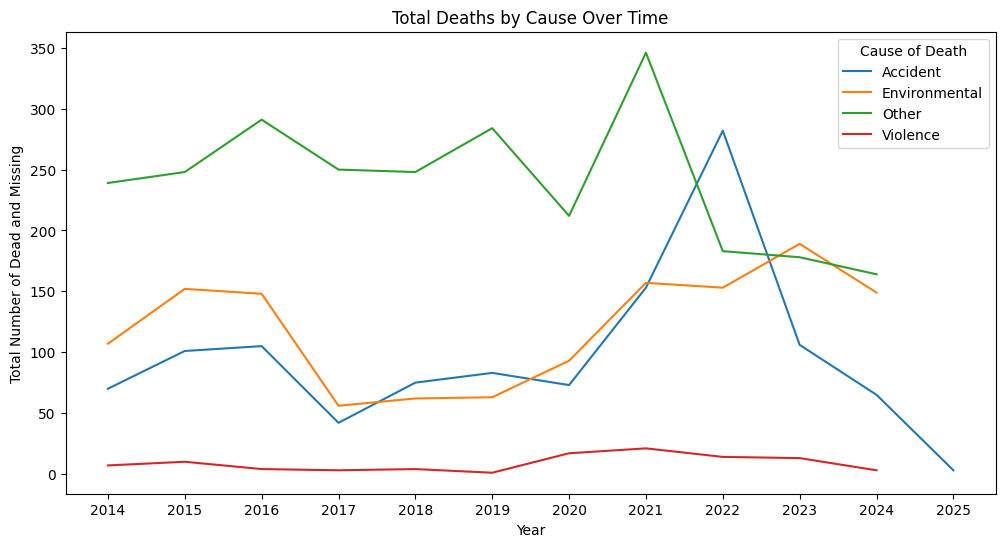

<Figure size 1200x600 with 0 Axes>

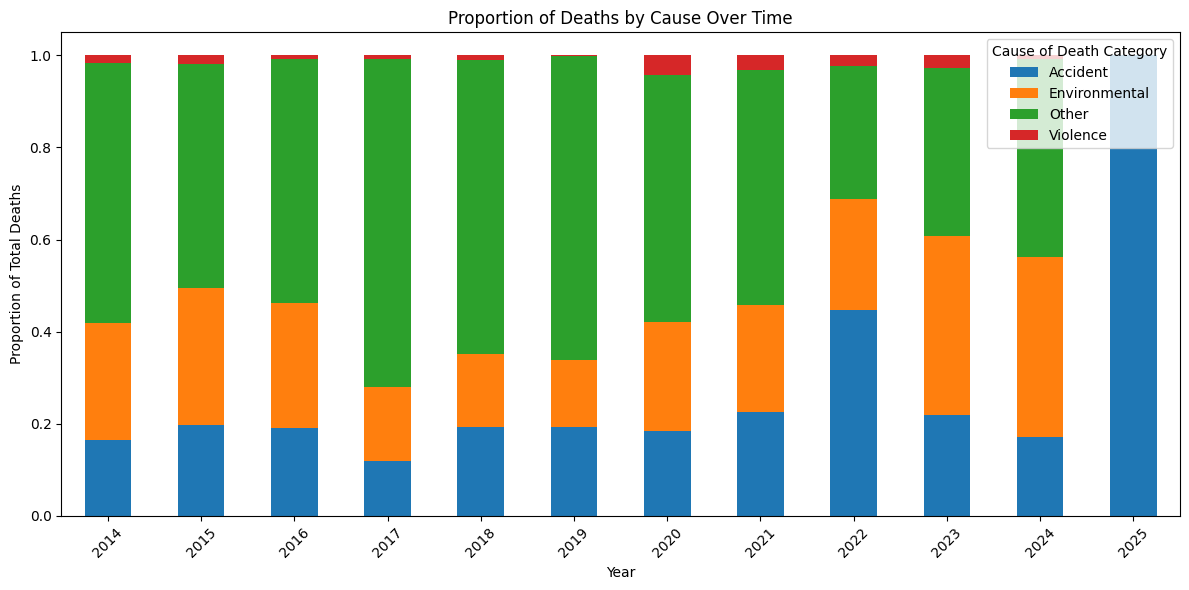

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line Chart for Top Causes
plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='Total Number of Dead and Missing', hue='Cause of Death Category', data=cause_counts)
plt.title('Total Deaths by Cause Over Time')
plt.xlabel('Year')
plt.ylabel('Total Number of Dead and Missing')
plt.xticks(cause_counts['year'].unique())
plt.legend(title='Cause of Death')
plt.show()

# Stacked Bar Chart for Proportions
plt.figure(figsize=(12, 6))
cause_counts_pivot = cause_counts.pivot(index='year', columns='Cause of Death Category', values='Proportion')
cause_counts_pivot.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Proportion of Deaths by Cause Over Time')
plt.xlabel('Year')
plt.ylabel('Proportion of Total Deaths')
plt.xticks(rotation=45)
plt.legend(title='Cause of Death Category')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# Create the line chart using Plotly Express
fig = px.line(cause_counts, x='year', y='Total Number of Dead and Missing', color='Cause of Death Category',
             hover_data=['Cause of Death Category', 'Total Number of Dead and Missing'],
             title='Total Deaths by Cause Over Time')

# Customize the hover information to show the cause clearly
fig.update_traces(hovertemplate='Year: %{x}<br>Cause: %{customdata[0]}<br>Deaths: %{y}')

# Export the plot as HTML
fig.write_html("plotly_line_chart.html")

fig.show()


In [ ]:
import plotly.express as px

# Create the line chart using plotly
fig = px.line(cause_counts, x='year', y='Total Number of Dead and Missing', color='Cause of Death Category',
             hover_data=['Total Number of Dead and Missing', 'Cause of Death Category'],
             title='Total Deaths by Cause Over Time')

fig.update_xaxes(title_text='Year')
fig.update_yaxes(title_text='Total Number of Dead and Missing')
fig.show()

# Download the visualization as an HTML file
fig.write_html("plotly_line_chart.html")


In [ ]:
import plotly.graph_objects as go

# Assuming 'cause_counts' DataFrame from the previous code

fig = go.Figure()

for cause in cause_counts['Cause of Death Category'].unique():
    cause_data = cause_counts[cause_counts['Cause of Death Category'] == cause]
    fig.add_trace(go.Bar(
        x=cause_data['year'],
        y=cause_data['Total Number of Dead and Missing'],
        name=cause,
        hovertemplate='Year: %{x}<br>Total Deaths: %{y}<extra></extra>' # Customize hover info
    ))

fig.update_layout(
    barmode='stack',
    title='Total Deaths by Cause Over Time',
    xaxis_title='Year',
    yaxis_title='Total Number of Dead and Missing',
    hovermode='x'  # Show hover info for all bars at the same x position
)

fig.show()

# Download the visualization as an HTML file
fig.write_html("stacked_bar_chart.html")


In [ ]:
# prompt: pie chart of total deaths by cause of death, such that when we hover cursor on the line, it will show us values and download plotly visualizations as html

import plotly.graph_objects as go

# Assuming 'cause_counts' DataFrame from the previous code

fig = go.Figure(data=[go.Pie(labels=cause_counts['Cause of Death Category'],
                             values=cause_counts['Total Number of Dead and Missing'],
                             hovertemplate='Cause: %{label}<br>Total Deaths: %{value}<extra></extra>')])

fig.update_layout(title='Total Deaths by Cause of Death')

fig.show()

# Download the Plotly visualization as an HTML file
fig.write_html("total_deaths_by_cause.html")


In [ ]:
# prompt:  pie chart of total deaths by cause of death, such that when we hover cursor on the line, it will show us values

import plotly.graph_objects as go

fig = go.Figure(data=[go.Pie(labels=cause_counts['Cause of Death Category'],
                             values=cause_counts['Total Number of Dead and Missing'],
                             hoverinfo='label+percent+value')])

fig.update_layout(title_text='Total Deaths by Cause of Death')

fig.show()


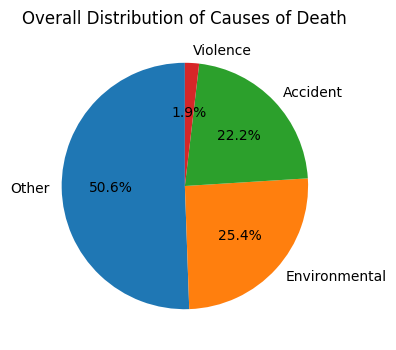

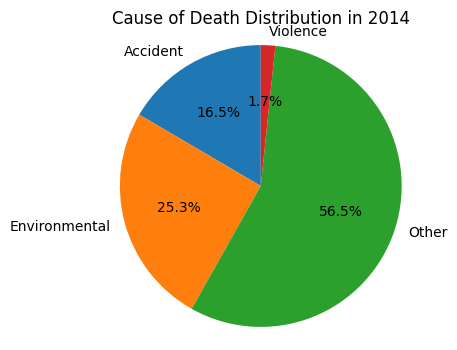

In [ ]:
import matplotlib.pyplot as plt
# Pie Chart for Cause Distribution (Overall)
plt.figure(figsize=(4, 4))
overall_primary_causes_by_count.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution of Causes of Death')
plt.ylabel('')  # Remove the y-axis label
plt.show()

# Pie Chart for Cause Distribution (Specific Year - example: 2014)
year_to_visualize = 2014 # Example year
cause_counts_year = cause_counts[cause_counts['year'] == year_to_visualize]

plt.figure(figsize=(4, 4))
plt.pie(cause_counts_year['Total Number of Dead and Missing'], labels=cause_counts_year['Cause of Death Category'], autopct='%1.1f%%', startangle=90)
plt.title(f'Cause of Death Distribution in {year_to_visualize}')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [ ]:
# prompt: download plotly visualizations as html

import plotly.io as pio

# ... (your existing code) ...

# Save the Plotly figures as HTML files
pio.write_html(fig, file='plotly_line_chart.html') # Line chart
pio.write_html(fig, file='plotly_stacked_bar_chart.html') # Stacked bar chart
pio.write_html(fig, file='plotly_pie_chart.html') # Pie chart


## Summary:

### 1. Q&A
What are the primary causes of death among migrants, and have these causes shifted over the years?

The primary causes of death among migrants show some variation over the years. "Other" consistently represents a substantial portion of deaths, followed by "Accident" and "Environmental" causes.  While "Other" is the leading cause overall, the relative contributions of "Accident" and "Environmental" causes fluctuate from year to year.  "Violence" consistently represents a smaller proportion of deaths.  In 2025, "Accident" appears as the sole cause of death in the dataset for that year.

### 2. Data Analysis Key Findings
* **"Other" is the most frequent primary cause of death across many years.**  This category likely encompasses a mix of undetermined or less-common causes.
* **"Accident" and "Environmental" causes fluctuate in their contribution to total deaths over time, but have emerged as primary causes in several years.** This suggests a potential relationship between environmental conditions and migrant fatalities.
* **In 2025, "Accident" was the only recorded cause of death in the data.** This warrants further investigation to determine if this is an anomaly due to data limitations for that year or a real shift in trends.
* **"Violence" consistently accounts for a smaller proportion of migrant deaths compared to "Other," "Accident," and "Environmental" categories.**


### 3. Insights or Next Steps
* **Investigate the "Other" category:**  Further analysis is needed to understand the composition of the "Other" category of deaths. This might involve reviewing the original death descriptions and refining the categorization process to improve the granularity of the analysis.
* **Analyze the 2025 data:** Given that "Accident" is the only recorded cause in 2025, further investigation is warranted to explore whether this is an anomaly in data collection or a genuine change in the pattern of fatalities.
